# Option 2 Trial — Radial Background Synthesis from Crystal Frames
### SSA — Diamond I11 Beamline | Run7_GLY_0.5VF_X2

**Purpose:**  
Trial the Option 2 background subtraction strategy, in which the FEP background  
is synthesised from the radial mean profile of classified crystal-hit frames,  
rather than from non-crystal (gas/solution) frames as in V0.

**Why this is needed:**  
The V0 pool approach used gas frames as background. Gas frames have less material  
in the beam path than a crystal-hit frame (nitrogen instead of solution bolus),  
so the FEP signal is systematically lower than during a crystal hit. This caused  
under-subtraction — only ~18% FEP peak reduction with no new crystallographic  
information recovered.

**The Option 2 idea:**  
A crystal-hit frame is the FEP+solution background plus sparse Bragg spots.  
Because spots cover only ~0.2% of pixels, the radial mean profile of a crystal  
frame is almost entirely the background. Pool those radial profiles from all  
crystal frames, reconstruct a smooth 2D background image, and subtract it.  
No dedicated blank frames required.

**Validation dataset:**  
Run7_GLY_0.5VF_X2 — glycine, 50 known crystal hits, previously tested in V0  
calibration. The V0 result and 1D subtraction result provide comparison benchmarks.

---
**Run cells in order. Each step has a markdown explanation above it.**

---
## Step 0 — Paths, imports, and configuration

Set all file paths here. Everything else in the notebook reads from these variables.  
The beam centre is read directly from the `.poni` calibration file — no manual entry needed.

In [1]:
import os, sys, glob, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm
from pathlib import Path

# ── File paths ────────────────────────────────────────────────────────────────
RAW_DATA_DIR = r"E:/I11BT_dec25_dlm_gly/Data_Processing/RAW_2D/Run7_GLY_0.5VF_X2/"
OUTPUT_DIR   = r"E:/I11BT_dec25_dlm_gly/Data_Processing/Trial_2D_Corrected/Option2_Glycine/"
MASK_PATH    = r"E:/I11BT_dec25_dlm_gly/Data_Processing/X2_Calib/X2_mask.npy"
PONI_PATH    = r"E:/I11BT_dec25_dlm_gly/Data_Processing/X2_Calib/X2_calib.poni"

# ── Module path — update if fep_subtraction_2d_i11_v1.py is in a different folder ──
MODULE_DIR = r"C:\Users\ezxsa27\I11_PXRD_SSA\I11_PXRD_processing_scripts\FEP_Subtraction\""
if MODULE_DIR not in sys.path:
    sys.path.insert(0, MODULE_DIR)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── File discovery ────────────────────────────────────────────────────────────
all_files = sorted(glob.glob(os.path.join(RAW_DATA_DIR, "i11-1-*.nxs")))
if len(all_files) == 0:
    all_files = sorted(glob.glob(os.path.join(RAW_DATA_DIR, "pixium_*.hdf")))
    print(f"Using .hdf files: {len(all_files)} found")
else:
    print(f"Using .nxs files: {len(all_files)} found")

if len(all_files) == 0:
    raise FileNotFoundError(f"No data files found in {RAW_DATA_DIR}")

# ── Mask ─────────────────────────────────────────────────────────────────────
mask = np.load(MASK_PATH)
print(f"Mask loaded: {mask.shape}  masked pixels: {mask.sum():,} ({100*mask.sum()/mask.size:.1f}%)")

# ── Beam centre from .poni ────────────────────────────────────────────────────
# Read Poni1, Poni2, and pixel size from the calibration file.
# Poni1 = beam centre in metres along axis 1 (rows, Y direction)
# Poni2 = beam centre in metres along axis 2 (cols, X direction)
# Beam centre in pixels = Poni / pixel_size
poni_vals = {}
with open(PONI_PATH) as f:
    for line in f:
        line = line.strip()
        if line.startswith('#') or ':' not in line:
            continue
        key, _, val = line.partition(':')
        poni_vals[key.strip()] = val.strip()

# Parse detector config for pixel size
import json as _json
det_cfg    = _json.loads(poni_vals.get('Detector_config', '{}'))
pixel_size = float(det_cfg.get('pixel1', 0.000148))   # metres
poni1      = float(poni_vals.get('Poni1', 0.0))       # metres
poni2      = float(poni_vals.get('Poni2', 0.0))       # metres

beam_cy = poni1 / pixel_size   # row (Y) in pixels
beam_cx = poni2 / pixel_size   # col (X) in pixels
BEAM_CENTRE_RC = (beam_cy, beam_cx)

print(f"\nCalibration (.poni):")
print(f"  Pixel size     : {pixel_size*1e6:.1f} µm")
print(f"  Poni1 (Y)      : {poni1*1000:.4f} mm  ->  row {beam_cy:.2f} px")
print(f"  Poni2 (X)      : {poni2*1000:.4f} mm  ->  col {beam_cx:.2f} px")
print(f"  Beam centre    : row={beam_cy:.2f}  col={beam_cx:.2f}")
print(f"  Geometric centre would be: row={2881/2:.1f}  col={2880/2:.1f}")
print(f"  Offset from geometric: {beam_cy - 2881/2:+.1f} rows  {beam_cx - 2880/2:+.1f} cols")

print(f"\n✅ Setup complete. Output dir: {OUTPUT_DIR}")

Using .nxs files: 196 found
Mask loaded: (2881, 2880)  masked pixels: 59,575 (0.7%)

Calibration (.poni):
  Pixel size     : 148.0 µm
  Poni1 (Y)      : 214.0484 mm  ->  row 1446.27 px
  Poni2 (X)      : 213.1642 mm  ->  col 1440.30 px
  Beam centre    : row=1446.27  col=1440.30
  Geometric centre would be: row=1440.5  col=1440.0
  Offset from geometric: +5.8 rows  +0.3 cols

✅ Setup complete. Output dir: E:/I11BT_dec25_dlm_gly/Data_Processing/Trial_2D_Corrected/Option2_Glycine/


---
## Step 1 — Import module and ground truth

Import the V1 module and define the 50 known crystal hits from the glycine dataset.  
These are used later to measure how well the classifier and subtraction perform.

In [2]:
import V1_fep_subtraction_2d_i11 as fep
print(hasattr(fep, 'learn_thresholds'))           # should be True
print(hasattr(fep, 'build_radial_background_from_crystal_frames'))  # should be True

True
True


In [3]:
import importlib
import V1_fep_subtraction_2d_i11 as fep
importlib.reload(fep)

from V1_fep_subtraction_2d_i11 import (
    learn_thresholds,
    classify_dataset,
    build_radial_background_from_crystal_frames,
    build_background_from_dataset,
    subtract_fep_2d,
    process_dataset,
    inspect_nexus,
    _load_pixium_frame,
)

# Ground truth: 50 confirmed crystal collection numbers (glycine Run7)
KNOWN_CRYSTAL_NUMBERS = [
    "122988","122993","122995","122996","122998","122999","123002","123012",
    "123022","123027","123037","123040","123042","123043","123056","123061",
    "123062","123069","123070","123071","123079","123081","123083","123085",
    "123086","123090","123093","123099","123100","123101","123102","123104",
    "123107","123108","123109","123110","123111","123112","123121","123122",
    "123131","123141","123142","123146","123148","123149","123150","123155",
    "123162","123172"
]

def extract_number(fp):
    stem = os.path.splitext(os.path.basename(fp))[0]
    for part in reversed(stem.replace("-","_").split("_")):
        if part.isdigit():
            return part
    return ""

all_numbers   = [extract_number(f) for f in all_files]
crystal_files = [f for f, n in zip(all_files, all_numbers) if n in KNOWN_CRYSTAL_NUMBERS]
miss_files    = [f for f, n in zip(all_files, all_numbers) if n not in KNOWN_CRYSTAL_NUMBERS]

print(f"Total files  : {len(all_files)}")
print(f"Crystal hits : {len(crystal_files)}  (ground truth)")
print(f"Misses       : {len(miss_files)}")
print("\n✅ Module imported.")

Total files  : 196
Crystal hits : 50  (ground truth)
Misses       : 146

✅ Module imported.


---
## Step 2 — Inspect a file and confirm detector path

Always run this on a new dataset to confirm the HDF5 structure  
and check the frame shape matches expectations (2881 × 2880 for Pixium at I11).

In [4]:
inspect_nexus(all_files[0])

frame = _load_pixium_frame(all_files[0])
if frame.ndim == 3:
    frame = frame[0]
print(f"Frame shape : {frame.shape}")
print(f"dtype       : {frame.dtype}")
print(f"min / max   : {frame.min():.0f} / {frame.max():.0f}")
print(f"mean        : {frame.mean():.1f}")


  i11-1-122980.nxs
  D entry1  [NXentry]
      D entry1/before_scan  [NXcollection]
            entry1/before_scan/pixium10_BaseExposure   shape=(1,)  dtype=float64
            entry1/before_scan/pixium10_ExcludeEarlyFrames   shape=(1,)  dtype=object
            entry1/before_scan/pixium10_PUMode   shape=(1,)  dtype=float64
            entry1/before_scan/pixium10_TotalCount   shape=(1,)  dtype=float64
            entry1/before_scan/pixium10_TriggerMode   shape=(1,)  dtype=object
      D entry1/calibrant  [NXsample]
            entry1/calibrant/name   shape=(1,)  dtype=object
        entry1/end_time   shape=()  dtype=object
        entry1/entry_identifier   shape=()  dtype=object
        entry1/experiment_identifier   shape=()  dtype=object
      D entry1/instrument  [NXinstrument]
          D entry1/instrument/ds  [NXpositioner]
                entry1/instrument/ds/ds   shape=(1,)  dtype=float64
                entry1/instrument/ds/soft_limit_max   shape=(1,)  dtype=float64
          

---
## Step 3 — Learn thresholds from the dataset

V1 learns classification thresholds from the data itself using a Gaussian mixture  
model fitted to the spot_density distribution. This replaces the hardcoded glycine  
thresholds from V0 and will generalise to other crystal systems.

**After this cell:** inspect `threshold_diagnostic.png` in the output directory  
before proceeding. The plot should show two clear peaks — one for background  
frames, one for crystal frames. If only one peak is visible, the separation  
score will be low and the fallback thresholds will be used.

In [5]:
learned_thresholds = learn_thresholds(
    all_files,
    output_dir    = OUTPUT_DIR,
    mask          = mask,
    dataset_label = "Run7_GLY_0.5VF_X2",
    save_plot     = True,
)

print(f"\nLearned thresholds summary:")
print(f"  Crystal threshold    : {learned_thresholds.crystal_threshold:.5f}  "
      f"({learned_thresholds.crystal_threshold*100:.4f}%)")
print(f"  Background threshold : {learned_thresholds.background_threshold:.5f}  "
      f"({learned_thresholds.background_threshold*100:.4f}%)")
print(f"  Separation score     : {learned_thresholds.separation_score:.3f}  "
      f"(>1.0 = clean separation)")
print(f"  BIC ratio            : {learned_thresholds.bic_ratio:.3f}  "
      f"(>1.05 = two populations present)")
print(f"  Fallback used        : {learned_thresholds.fallback_used}")
print(f"  Est. crystal frames  : {learned_thresholds.n_crystal_estimated}")
print(f"  Est. background frames: {learned_thresholds.n_background_estimated}")
print(f"\n  --> Inspect: {os.path.join(OUTPUT_DIR, 'threshold_diagnostic.png')}")


learn_thresholds: scoring 196 frames (from 196 total) ...
  Scored 50/196 frames
  Scored 100/196 frames
  Scored 150/196 frames
  Scored 196/196 frames

  196 frames scored.  mean=0.00434  std=0.00082  min=0.00010  max=0.00572
  GMM: converged=True  BIC ratio=0.917  separation=9.248
  Background: mu=0.00012  sig=0.00002  w=0.03
  Crystal:    mu=0.00445  sig=0.00045  w=0.97


C:\Users\ezxsa27\AppData\Local\Temp\ipykernel_30372\1420098088.py:1: UserWarning: GMM did not find clean separation (separation=9.248, BIC ratio=0.917). Using V0 glycine-calibrated fallback thresholds.
  learned_thresholds = learn_thresholds(



  Saved: E:\I11BT_dec25_dlm_gly\Data_Processing\Trial_2D_Corrected\Option2_Glycine\thresholds.json
  Saved: E:\I11BT_dec25_dlm_gly\Data_Processing\Trial_2D_Corrected\Option2_Glycine\threshold_diagnostic.png
  Est. crystal frames    : 191
  Est. background frames : 5
────────────────────────────────────────────────────────────


Learned thresholds summary:
  Crystal threshold    : 0.00220  (0.2200%)
  Background threshold : 0.00050  (0.0500%)
  Separation score     : 9.248  (>1.0 = clean separation)
  BIC ratio            : 0.917  (>1.05 = two populations present)
  Fallback used        : True
  Est. crystal frames  : 191
  Est. background frames: 5

  --> Inspect: E:/I11BT_dec25_dlm_gly/Data_Processing/Trial_2D_Corrected/Option2_Glycine/threshold_diagnostic.png


---
## Step 4 — Classify the dataset

Apply the learned thresholds to classify every frame.  
Crystal frames will be used both as the source of the synthesised background  
and as the frames to be corrected. Check the classification summary against  
the known ground truth (50 crystal hits).

In [6]:
csv_path = os.path.join(OUTPUT_DIR, "glycine_classification_option2.csv")

all_metrics = classify_dataset(
    all_files,
    mask                = mask,
    csv_output          = csv_path,
    learned_thresholds  = learned_thresholds,
)

# Compare against ground truth
crystal_auto = [m for m in all_metrics if m.auto_class == "crystal"]
crystal_nums_auto = {extract_number(m.filepath) for m in crystal_auto}
crystal_nums_true = set(KNOWN_CRYSTAL_NUMBERS)

tp = len(crystal_nums_auto & crystal_nums_true)
fp = len(crystal_nums_auto - crystal_nums_true)
fn = len(crystal_nums_true - crystal_nums_auto)

print(f"\n=== Classification vs ground truth ===")
print(f"  True positives  : {tp} / {len(crystal_nums_true)}")
print(f"  False positives : {fp}")
print(f"  False negatives : {fn}")

uncertain_count = sum(1 for m in all_metrics if m.auto_class == "uncertain")
print(f"  Uncertain frames: {uncertain_count}  (see CSV for manual review)")


────────────────────────────────────────────────────────────────
  Dataset classification  (196 frames from 196 files)
────────────────────────────────────────────────────────────────
  crystal       191 frames  ██████████████████████████████████████
  solution        5 frames  █
  gas             0 frames  
  uncertain       0 frames  
────────────────────────────────────────────────────────────────

  Top crystal candidates:
    score=1.000  i11-1-122980.nxs  frame=0
    score=1.000  i11-1-122981.nxs  frame=0
    score=1.000  i11-1-122982.nxs  frame=0
    score=1.000  i11-1-122983.nxs  frame=0
    score=1.000  i11-1-122984.nxs  frame=0
    score=1.000  i11-1-122985.nxs  frame=0
    score=1.000  i11-1-122986.nxs  frame=0
    score=1.000  i11-1-122987.nxs  frame=0
    score=1.000  i11-1-122988.nxs  frame=0
    score=1.000  i11-1-122989.nxs  frame=0

  ML training CSV: E:/I11BT_dec25_dlm_gly/Data_Processing/Trial_2D_Corrected/Option2_Glycine/glycine_classification_option2.csv


=== Cla

---
## Step 5 — Build Option 2 radial background

This is the core of Option 2. The function:
1. Selects all classified crystal frames (strongest hits first)
2. Loads each frame and computes its radial mean profile using the **true beam centre** from the `.poni` file
3. Averages all profiles into a single master profile
4. Smooths it to reduce per-frame statistical noise
5. Reconstructs a 2D background image by assigning each pixel the profile value at its radius

For comparison, the V0 pool background is also built here.

In [7]:
print("Building Option 2 radial background...")
bg_radial, bg_type_radial, n_radial = build_radial_background_from_crystal_frames(
    all_metrics,
    beam_centre_rc = BEAM_CENTRE_RC,
    mask           = mask,
    smooth_window  = 21,
)
print(f"  Option 2 background: {bg_type_radial}")
print(f"  Frames used        : {n_radial}")
print(f"  Shape              : {bg_radial.shape}")
print(f"  Mean / max         : {bg_radial.mean():.1f} / {bg_radial.max():.1f}")

print("\nBuilding V0 pool background for comparison...")
try:
    bg_pool, bg_type_pool, n_pool = build_background_from_dataset(
        all_metrics,
    )
    print(f"  Pool background: {bg_type_pool}")
    print(f"  Frames used    : {n_pool}")
    print(f"  Mean / max     : {bg_pool.mean():.1f} / {bg_pool.max():.1f}")
    pool_available = True
except Exception as e:
    print(f"  Pool background unavailable: {e}")
    pool_available = False

Building Option 2 radial background...
  Option 2 background: radial_crystal_frames
  Frames used        : 50
  Shape              : (2881, 2880)
  Mean / max         : 273.1 / 11893.4

Building V0 pool background for comparison...
  Pool background: solution
  Frames used    : 5
  Mean / max     : 19.9 / 11045.4


---
## Step 6 — Visual inspection of the backgrounds

Plot the two background images side by side, then plot their radial profiles.  

**What to look for:**
- The Option 2 background should show the same FEP ring structure as the raw frames
- The radial profiles should match the shape of a typical crystal-hit frame's profile
- The V0 pool background may show a lower overall level if derived from gas frames
- Any residual Bragg spot contamination in the Option 2 background will appear as  
  localised bright spots — these should be minimal

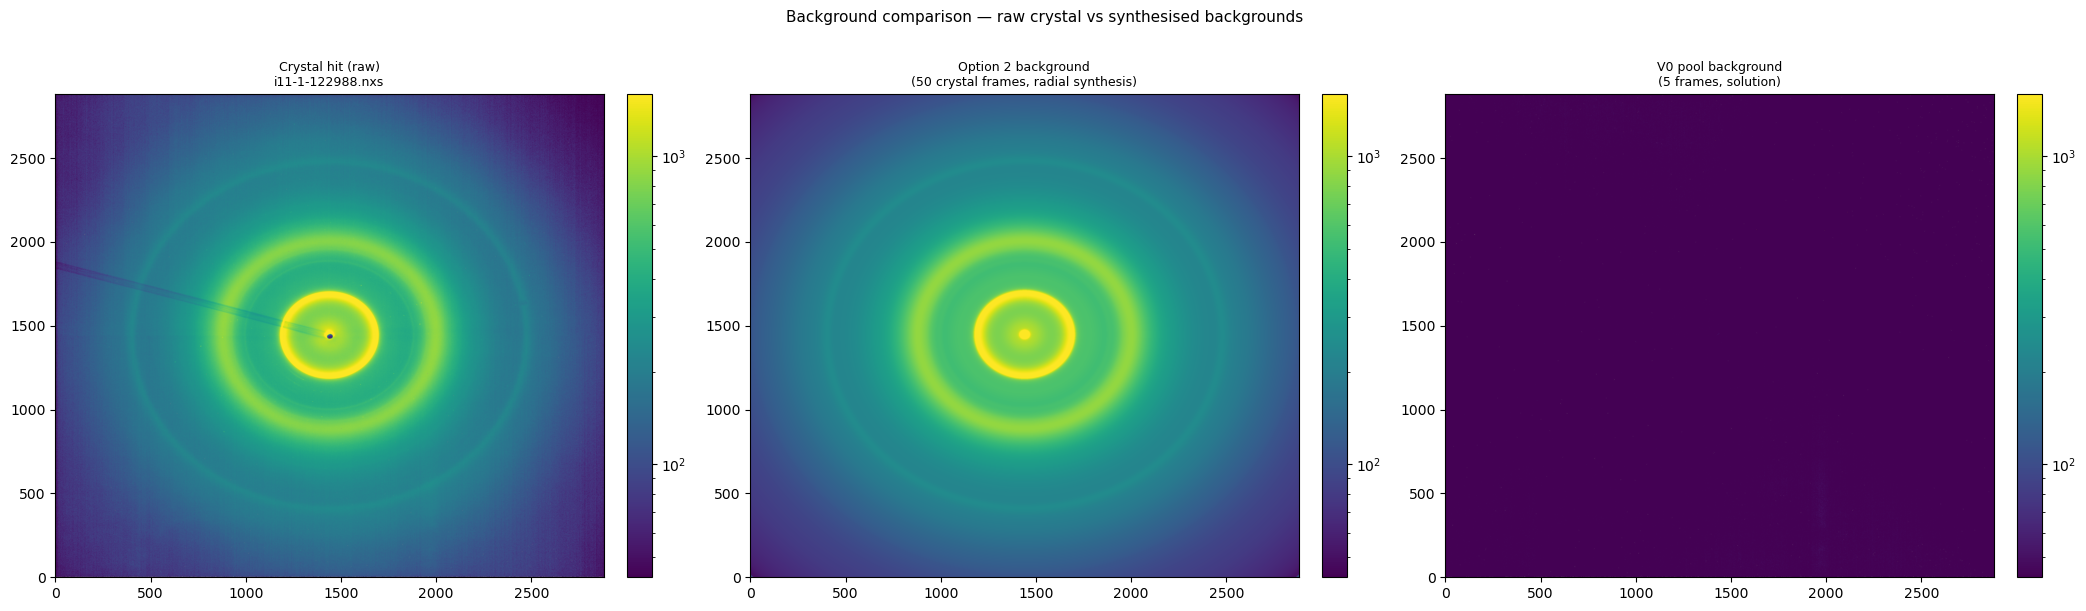

Saved: background_comparison_2D.png


In [8]:
%matplotlib inline

n_panels = 3 if pool_available else 2
fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 6))

# Load a representative crystal frame for comparison
ref_crystal_fp = crystal_files[0]
ref_frame = _load_pixium_frame(ref_crystal_fp)
if ref_frame.ndim == 3:
    ref_frame = ref_frame[0]

vmin = max(1, float(np.percentile(ref_frame[ref_frame > 0], 1)))
vmax = float(np.percentile(ref_frame, 99.5))
norm = LogNorm(vmin=vmin, vmax=vmax)

panels = [(ref_frame, f"Crystal hit (raw)\n{os.path.basename(ref_crystal_fp)}"),
          (bg_radial, f"Option 2 background\n({n_radial} crystal frames, radial synthesis)")]
if pool_available:
    panels.append((bg_pool, f"V0 pool background\n({n_pool} frames, {bg_type_pool})"))

for ax, (img, title) in zip(axes, panels):
    im = ax.imshow(img, origin="lower", norm=norm, cmap="viridis", aspect="auto")
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Background comparison — raw crystal vs synthesised backgrounds",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "background_comparison_2D.png"), dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved: background_comparison_2D.png")

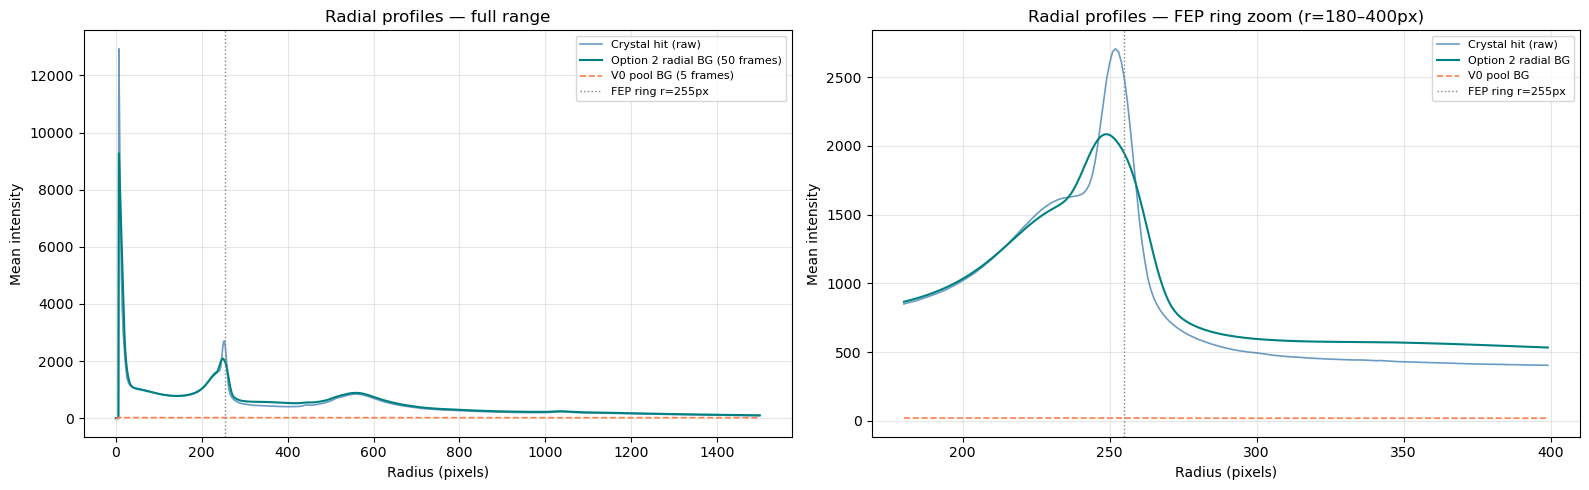

Saved: radial_profile_comparison.png

At FEP ring (r=255px):
  Crystal frame intensity : 2487.0
  Option 2 background     : 1943.7  (78.2% of crystal)
  V0 pool background      : 22.2  (0.9% of crystal)


In [9]:
# Radial profile comparison
rows, cols = ref_frame.shape
cy, cx = BEAM_CENTRE_RC
y_idx, x_idx = np.ogrid[:rows, :cols]
r_map = np.sqrt((x_idx - cx)**2 + (y_idx - cy)**2).astype(np.int32)
r_max = int(r_map.max())

def radial_profile(img, r_map, r_max, mask=None):
    arr = img.astype(np.float64)
    valid = arr > 0
    if mask is not None:
        valid &= ~mask.astype(bool)
    s = np.bincount(r_map[valid].ravel(), weights=arr[valid].ravel(), minlength=r_max+1)
    c = np.bincount(r_map[valid].ravel(), minlength=r_max+1)
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(c > 0, s / c, 0.0)

rp_crystal = radial_profile(ref_frame, r_map, r_max, mask)
rp_radial  = radial_profile(bg_radial,  r_map, r_max, mask)
if pool_available:
    rp_pool = radial_profile(bg_pool, r_map, r_max, mask)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Full range
r_axis = np.arange(min(r_max + 1, 1500))
axes[0].plot(r_axis, rp_crystal[:len(r_axis)], lw=1.2, color='steelblue',
             label='Crystal hit (raw)', alpha=0.8)
axes[0].plot(r_axis, rp_radial[:len(r_axis)],  lw=1.5, color='teal',
             label=f'Option 2 radial BG ({n_radial} frames)')
if pool_available:
    axes[0].plot(r_axis, rp_pool[:len(r_axis)], lw=1.2, color='coral', ls='--',
                 label=f'V0 pool BG ({n_pool} frames)')
axes[0].axvline(255, color='gray', ls=':', lw=1, label='FEP ring r=255px')
axes[0].set_xlabel('Radius (pixels)')
axes[0].set_ylabel('Mean intensity')
axes[0].set_title('Radial profiles — full range')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# FEP ring zoom
lo, hi = 180, 400
axes[1].plot(r_axis[lo:hi], rp_crystal[lo:hi], lw=1.2, color='steelblue',
             label='Crystal hit (raw)', alpha=0.8)
axes[1].plot(r_axis[lo:hi], rp_radial[lo:hi],  lw=1.5, color='teal',
             label='Option 2 radial BG')
if pool_available:
    axes[1].plot(r_axis[lo:hi], rp_pool[lo:hi], lw=1.2, color='coral', ls='--',
                 label='V0 pool BG')
axes[1].axvline(255, color='gray', ls=':', lw=1, label='FEP ring r=255px')
axes[1].set_xlabel('Radius (pixels)')
axes[1].set_ylabel('Mean intensity')
axes[1].set_title('Radial profiles — FEP ring zoom (r=180–400px)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "radial_profile_comparison.png"), dpi=150)
plt.show()
print("Saved: radial_profile_comparison.png")

# Print level comparison at FEP peak
fep_r = 255
print(f"\nAt FEP ring (r={fep_r}px):")
print(f"  Crystal frame intensity : {rp_crystal[fep_r]:.1f}")
print(f"  Option 2 background     : {rp_radial[fep_r]:.1f}  "
      f"({100*rp_radial[fep_r]/rp_crystal[fep_r]:.1f}% of crystal)")
if pool_available:
    print(f"  V0 pool background      : {rp_pool[fep_r]:.1f}  "
          f"({100*rp_pool[fep_r]/rp_crystal[fep_r]:.1f}% of crystal)")

---
## Step 7 — Single frame subtraction diagnostic

Subtract the Option 2 background from one crystal frame and inspect the result.  
This is the pixel-level check before running the full dataset.

**What to look for in the 2D images:**
- The FEP ring in the corrected frame should be strongly reduced or gone
- Bragg spots should still be visible (bright dots above the now-flat background)
- The corrected image should look like a dark frame with spots, not a bright ring frame

**What to look for in the residual:**
- After subtraction, negative pixels indicate over-subtraction (too much removed)
- A small percentage of negative pixels is normal and handled by clipping
- If >10% are negative, the background level is too high

Single-frame subtraction diagnostic: i11-1-122988.nxs
  Raw frame mean / max       : 246.9 / 42246
  Option 2 BG mean / max     : 273.1 / 11893.4
  Corrected mean / max       : 4.2 / 32521
  Negative pixels (pre-clip) : 6,712,156 (80.90%)
  ⚠️  >10% negative — background may be over-estimating FEP level

  V0 pool corrected mean     : 227.1
  V0 pool negative pixels    : 4,075 (0.05%)


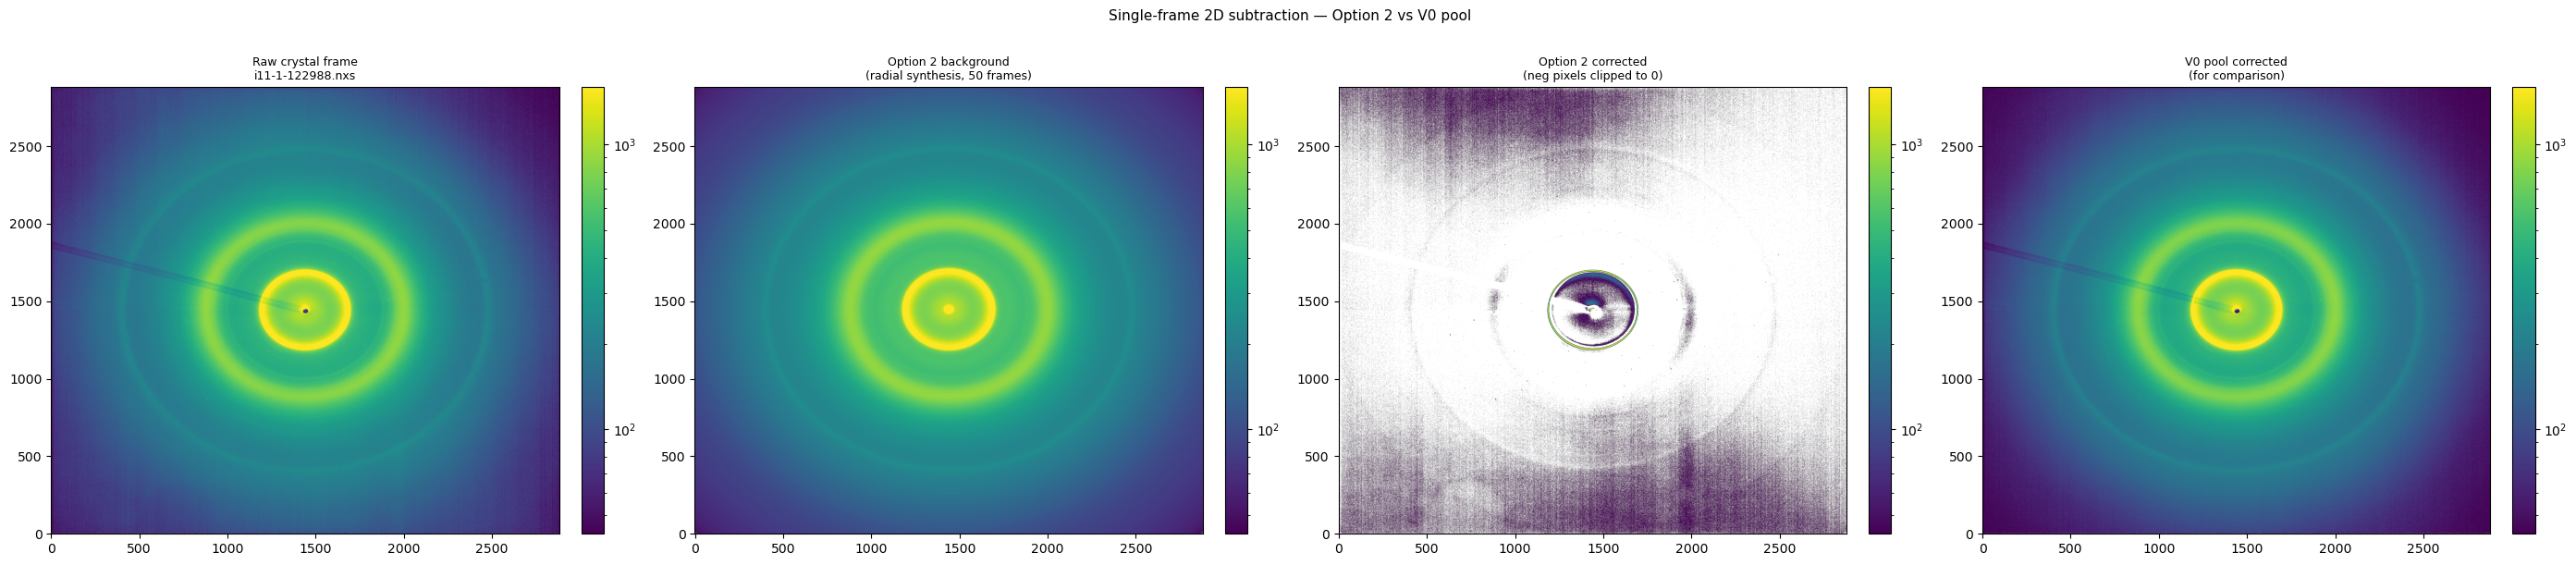


Saved: single_frame_subtraction_2D.png


In [10]:
%matplotlib inline

# Pick the first known crystal hit for the single-frame diagnostic
test_fp = crystal_files[0]
test_frame = _load_pixium_frame(test_fp)
if test_frame.ndim == 3:
    test_frame = test_frame[0]
test_frame = test_frame.astype(np.float64)

corrected_radial = np.clip(test_frame - bg_radial, 0.0, None)
if pool_available:
    corrected_pool = np.clip(test_frame - bg_pool, 0.0, None)

# Pixel stats before clipping
residual_raw_radial = test_frame - bg_radial
n_neg_radial = int(np.sum(residual_raw_radial < 0))
pct_neg_radial = 100 * n_neg_radial / test_frame.size

if pool_available:
    residual_raw_pool = test_frame - bg_pool
    n_neg_pool = int(np.sum(residual_raw_pool < 0))
    pct_neg_pool = 100 * n_neg_pool / test_frame.size

print(f"Single-frame subtraction diagnostic: {os.path.basename(test_fp)}")
print(f"  Raw frame mean / max       : {test_frame.mean():.1f} / {test_frame.max():.0f}")
print(f"  Option 2 BG mean / max     : {bg_radial.mean():.1f} / {bg_radial.max():.1f}")
print(f"  Corrected mean / max       : {corrected_radial.mean():.1f} / {corrected_radial.max():.0f}")
print(f"  Negative pixels (pre-clip) : {n_neg_radial:,} ({pct_neg_radial:.2f}%)")
if pct_neg_radial > 10:
    print("  ⚠️  >10% negative — background may be over-estimating FEP level")
if pool_available:
    print(f"\n  V0 pool corrected mean     : {corrected_pool.mean():.1f}")
    print(f"  V0 pool negative pixels    : {n_neg_pool:,} ({pct_neg_pool:.2f}%)")

# 2D image comparison
n_panels = 4 if pool_available else 3
fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 6))

vmin = max(1, float(np.percentile(test_frame[test_frame > 0], 1)))
vmax = float(np.percentile(test_frame, 99.5))
norm = LogNorm(vmin=vmin, vmax=vmax)

panels = [
    (test_frame,       f"Raw crystal frame\n{os.path.basename(test_fp)}"),
    (bg_radial,        f"Option 2 background\n(radial synthesis, {n_radial} frames)"),
    (corrected_radial, f"Option 2 corrected\n(neg pixels clipped to 0)"),
]
if pool_available:
    panels.append((corrected_pool, f"V0 pool corrected\n(for comparison)"))

for ax, (img, title) in zip(axes, panels):
    im = ax.imshow(img, origin="lower", norm=norm, cmap="viridis", aspect="auto")
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Single-frame 2D subtraction — Option 2 vs V0 pool",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "single_frame_subtraction_2D.png"), dpi=150,
            bbox_inches="tight")
plt.show()
print("\nSaved: single_frame_subtraction_2D.png")

### Step 7b — Auto scale factor from flat detector region
The overall mean ratio between the radial background and the test frame is >1.0, meaning the pooled background is slightly brighter than this specific frame on average. This is caused by beam intensity drift across the run — the crystal frames that built the background pool had slightly higher beam intensity than this frame.
Fixing this with a single hardcoded scale factor won't generalise frame to frame. Instead we compute a per-frame scale factor by matching the background level to the frame level in a flat, featureless region of the detector (r=400–800px) — away from the FEP ring and any Bragg spots. This handles drift automatically.

Frame median in flat region : 450.0
BG median in flat region    : 531.2
Auto scale factor           : 0.8471
(Compare: fixed scale=0.5 gave 0.89% negative pixels)
Negative pixels at auto SF  : 33.08%

At FEP ring (r=255px) with auto SF:
  Raw                 : 2487.0
  BG * auto_sf        : 1646.6
  Expected residual   : 840.4


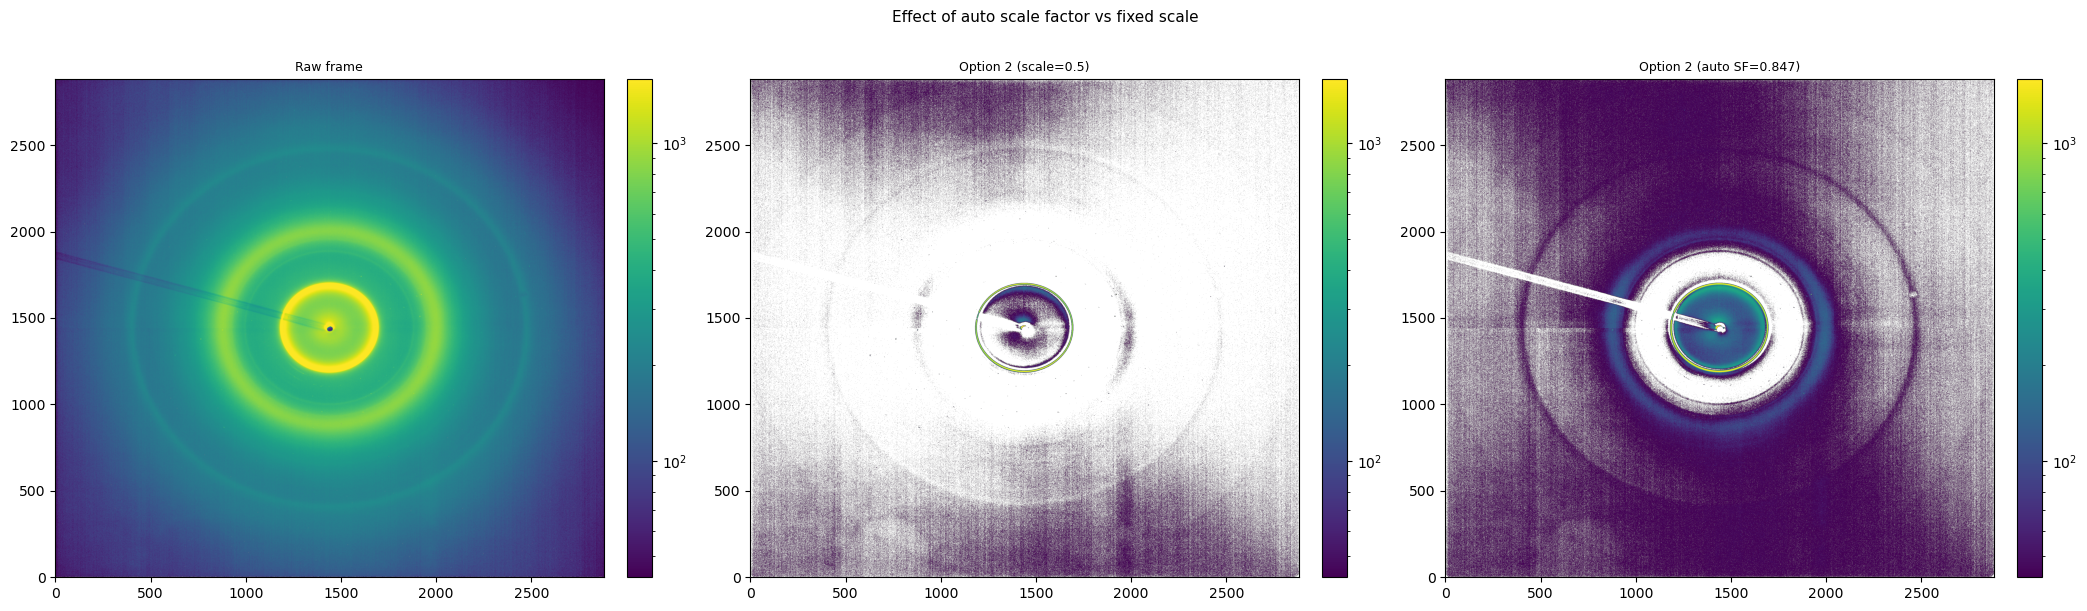

Saved: auto_scale_factor_comparison.png


In [19]:
# Per-frame auto scale factor from flat background region
region = (r_map >= 400) & (r_map <= 800)
if mask is not None:
    region &= ~mask.astype(bool)

frame_level = np.median(test_frame[region])
bg_level    = np.median(bg_radial[region])
auto_sf     = frame_level / bg_level

print(f"Frame median in flat region : {frame_level:.1f}")
print(f"BG median in flat region    : {bg_level:.1f}")
print(f"Auto scale factor           : {auto_sf:.4f}")
print(f"(Compare: fixed scale=0.5 gave 0.89% negative pixels)")

corrected_auto = np.clip(test_frame - auto_sf * bg_radial, 0, None)
residual_auto  = test_frame - auto_sf * bg_radial
n_neg_auto     = 100 * np.sum(residual_auto < 0) / test_frame.size
print(f"Negative pixels at auto SF  : {n_neg_auto:.2f}%")

# Also recheck FEP ring ratio with auto scale applied
print(f"\nAt FEP ring (r=255px) with auto SF:")
print(f"  Raw                 : {rp_crystal[255]:.1f}")
print(f"  BG * auto_sf        : {rp_radial[255] * auto_sf:.1f}")
print(f"  Expected residual   : {rp_crystal[255] - rp_radial[255]*auto_sf:.1f}")

# Visual check — repeat the 2D panel plot with auto SF
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
vmin = max(1, float(np.percentile(test_frame[test_frame > 0], 1)))
vmax = float(np.percentile(test_frame, 99.5))
norm = LogNorm(vmin=vmin, vmax=vmax)

panels = [
    (test_frame,       f"Raw frame"),
    (corrected_radial, f"Option 2 (scale=0.5)"),
    (corrected_auto,   f"Option 2 (auto SF={auto_sf:.3f})"),
]
for ax, (img, title) in zip(axes, panels):
    im = ax.imshow(img, origin="lower", norm=norm, cmap="viridis", aspect="auto")
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Effect of auto scale factor vs fixed scale", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "auto_scale_factor_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: auto_scale_factor_comparison.png")

---
## Step 8 — pyFAI integration and 1D pattern comparison

Integrate the raw, Option 2 corrected, and V0 pool corrected frames using pyFAI  
to produce 1D patterns and compare the FEP peak region.

**What to look for:**
- At ~5.8° 2θ the FEP peak should be reduced in the corrected patterns
- Option 2 should show a larger reduction than V0 pool (~18%) if the approach is working
- Glycine Bragg peaks (at known positions) should be preserved or enhanced
- The baseline between peaks should be lower in the corrected patterns

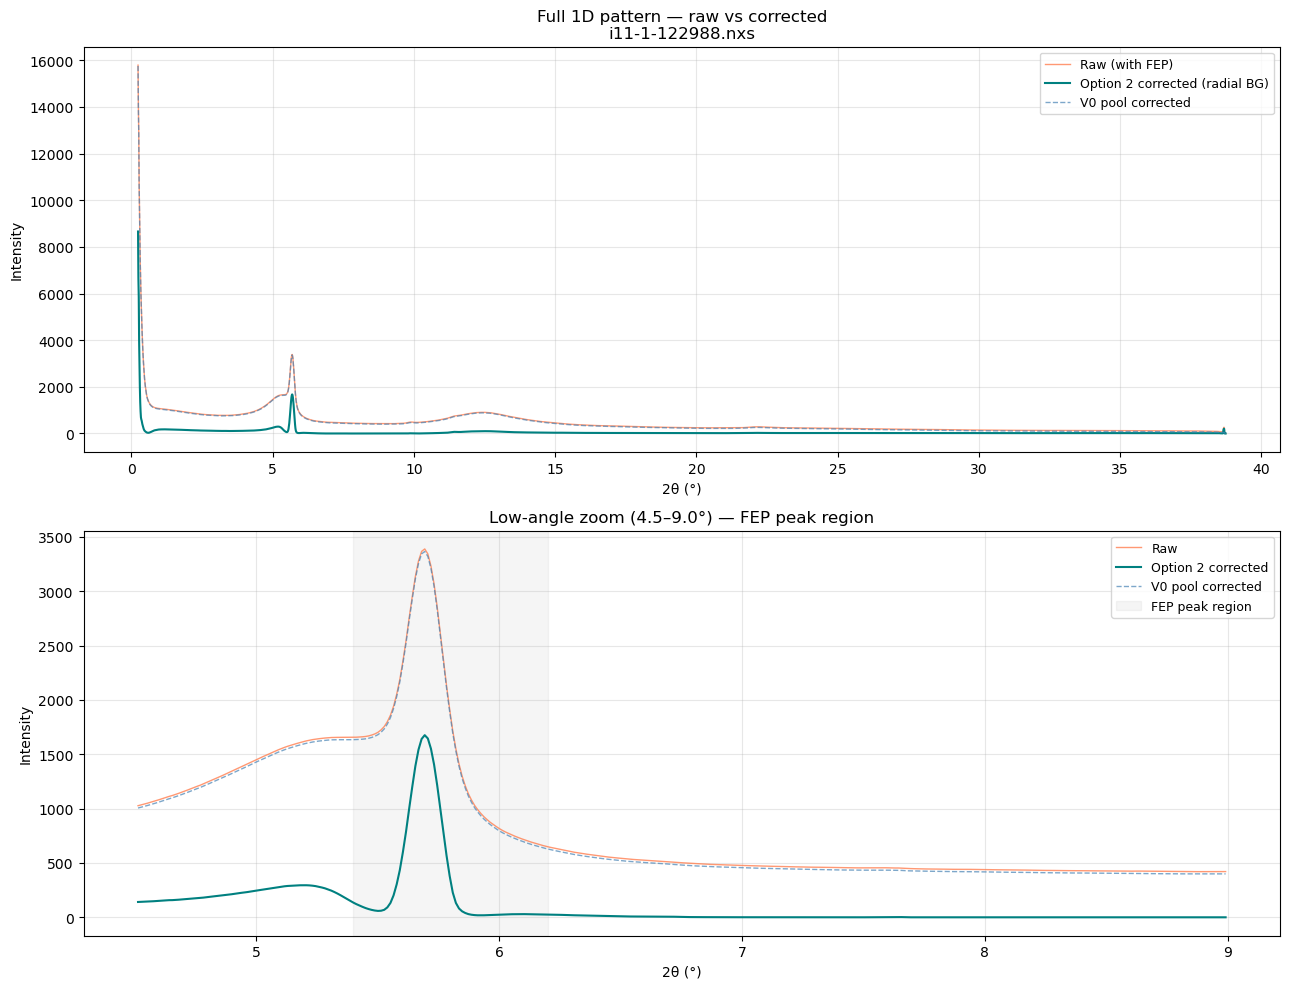

Saved: 1D_pattern_comparison.png

FEP peak reduction (5.4–6.2° 2θ):
  Raw peak max           : 3389
  Option 2 peak max      : 1676  reduction: 50.5%
  V0 pool peak max       : 3365  reduction: 0.7%
  V0 baseline (reported) : ~18%  reduction


In [20]:
%matplotlib inline

try:
    import pyFAI
    ai = pyFAI.load(PONI_PATH)
    npt = 3000
    mask_int = mask.astype(np.int32)

    # Integrate all three frames
    r_raw    = ai.integrate1d(test_frame.astype(np.float32),      npt, mask=mask_int, unit="2th_deg")
    r_opt2   = ai.integrate1d(corrected_auto.astype(np.float32), npt, mask=mask_int, unit="2th_deg")
    if pool_available:
        r_pool = ai.integrate1d(corrected_pool.astype(np.float32), npt, mask=mask_int, unit="2th_deg")

    tth_raw,  i_raw  = np.array(r_raw[0]),  np.array(r_raw[1])
    tth_opt2, i_opt2 = np.array(r_opt2[0]), np.array(r_opt2[1])
    if pool_available:
        tth_pool, i_pool = np.array(r_pool[0]), np.array(r_pool[1])

    fig, axes = plt.subplots(2, 1, figsize=(13, 10))

    # Full pattern
    axes[0].plot(tth_raw,  i_raw,  lw=1.0, color='coral',     alpha=0.8, label='Raw (with FEP)')
    axes[0].plot(tth_opt2, i_opt2, lw=1.5, color='teal',      label='Option 2 corrected (radial BG)')
    if pool_available:
        axes[0].plot(tth_pool, i_pool, lw=1.0, color='steelblue', ls='--',
                     label='V0 pool corrected', alpha=0.7)
    axes[0].set_xlabel("2θ (°)")
    axes[0].set_ylabel("Intensity")
    axes[0].set_title(f"Full 1D pattern — raw vs corrected\n{os.path.basename(test_fp)}")
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    # FEP peak zoom
    lo_tth, hi_tth = 4.5, 9.0
    m_r   = (tth_raw  >= lo_tth) & (tth_raw  <= hi_tth)
    m_o2  = (tth_opt2 >= lo_tth) & (tth_opt2 <= hi_tth)
    axes[1].plot(tth_raw[m_r],   i_raw[m_r],   lw=1.0, color='coral',     alpha=0.8, label='Raw')
    axes[1].plot(tth_opt2[m_o2], i_opt2[m_o2], lw=1.5, color='teal',      label='Option 2 corrected')
    if pool_available:
        m_p = (tth_pool >= lo_tth) & (tth_pool <= hi_tth)
        axes[1].plot(tth_pool[m_p], i_pool[m_p], lw=1.0, color='steelblue', ls='--',
                     label='V0 pool corrected', alpha=0.7)
    axes[1].axvspan(5.4, 6.2, alpha=0.08, color='gray', label='FEP peak region')
    axes[1].set_xlabel("2θ (°)")
    axes[1].set_ylabel("Intensity")
    axes[1].set_title(f"Low-angle zoom ({lo_tth}–{hi_tth}°) — FEP peak region")
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "1D_pattern_comparison.png"), dpi=150)
    plt.show()
    print("Saved: 1D_pattern_comparison.png")

    # FEP peak reduction statistics
    fep_m_r  = (tth_raw  >= 5.4) & (tth_raw  <= 6.2)
    fep_m_o2 = (tth_opt2 >= 5.4) & (tth_opt2 <= 6.2)
    fep_raw  = i_raw[fep_m_r].max()
    fep_opt2 = i_opt2[fep_m_o2].max()
    print(f"\nFEP peak reduction (5.4–6.2° 2θ):")
    print(f"  Raw peak max           : {fep_raw:.0f}")
    print(f"  Option 2 peak max      : {fep_opt2:.0f}  "
          f"reduction: {100*(fep_raw-fep_opt2)/fep_raw:.1f}%")
    if pool_available:
        fep_m_p  = (tth_pool >= 5.4) & (tth_pool <= 6.2)
        fep_pool = i_pool[fep_m_p].max()
        print(f"  V0 pool peak max       : {fep_pool:.0f}  "
              f"reduction: {100*(fep_raw-fep_pool)/fep_raw:.1f}%")
    print(f"  V0 baseline (reported) : ~18%  reduction")

except ImportError:
    print("pyFAI not installed — skipping 1D integration. pip install pyFAI to enable.")

In [21]:
#Scale Factor Test 
# Check what scale factor is being used and negative pixel fraction
test_frame = _load_pixium_frame(crystal_files[0])
if test_frame.ndim == 3:
    test_frame = test_frame[0]
test_frame = test_frame.astype(np.float64)

for sf in [0.3, 0.4, 0.45, 0.5, 0.55, 0.6]:
    corrected = test_frame - sf * bg_radial
    n_neg = int(np.sum(corrected < 0))
    pct   = 100 * n_neg / corrected.size
    # Also check what's left at the FEP ring
    corrected_clipped = np.clip(corrected, 0, None)
    print(f"  scale={sf:.2f}  negative: {pct:.2f}%  "
          f"corrected mean: {corrected_clipped.mean():.1f}  "
          f"corrected max: {corrected_clipped.max():.0f}")

  scale=0.30  negative: 0.20%  corrected mean: 165.1  corrected max: 39328
  scale=0.40  negative: 0.37%  corrected mean: 137.9  corrected max: 38356
  scale=0.45  negative: 0.56%  corrected mean: 124.3  corrected max: 37870
  scale=0.50  negative: 0.89%  corrected mean: 110.7  corrected max: 37383
  scale=0.55  negative: 1.44%  corrected mean: 97.1  corrected max: 36897
  scale=0.60  negative: 2.41%  corrected mean: 83.6  corrected max: 36411


In [18]:
fep_r = 255
print(f"At FEP ring (r={fep_r}px):")
print(f"  Raw frame value    : {rp_crystal[fep_r]:.1f}")
print(f"  Radial BG value    : {rp_radial[fep_r]:.1f}")
print(f"  Ratio BG/frame     : {rp_radial[fep_r]/rp_crystal[fep_r]:.3f}")
print(f"  Overall mean ratio : {bg_radial.mean()/test_frame.mean():.3f}")

At FEP ring (r=255px):
  Raw frame value    : 2487.0
  Radial BG value    : 1943.7
  Ratio BG/frame     : 0.782
  Overall mean ratio : 1.106


---
## Step 9 — Batch processing with Option 2 background

Run the full pipeline on all crystal frames using the Option 2 background mode.  
Corrected NeXus files are written to the output directory, ready for pyFAI integration.

In [22]:
import os
from pathlib import Path
from V1_fep_subtraction_2d_i11 import subtract_fep_2d, _load_pixium_frame

output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

processed = []
skipped   = []

for m in all_metrics:
    fp  = Path(m.filepath)
    out = output_dir / f"{fp.stem}_opt2_corrected{fp.suffix}"

    if m.auto_class == "crystal":
        try:
            # Load the frame to compute its own scale factor
            frame = _load_pixium_frame(fp, m.frame_index)
            if frame.ndim == 3:
                frame = frame[0]
            frame = frame.astype(np.float64)

            # Compute per-frame scale factor from flat detector region
            # r=400-800px: away from FEP ring and Bragg spots
            region = (r_map >= 400) & (r_map <= 800)
            if mask is not None:
                region &= ~mask.astype(bool)

            frame_level = np.median(frame[region])
            bg_level    = np.median(bg_radial[region])
            frame_sf    = frame_level / bg_level if bg_level > 0 else 1.0

            subtract_fep_2d(
                data_filepath       = fp,
                background          = bg_radial,
                output_filepath     = out,
                background_type     = bg_type_radial,
                n_background_frames = n_radial,
                frame_index         = m.frame_index,
                scale_factor        = frame_sf,
                clip_negative       = True,
            )
            processed.append(out)
            print(f"  OK  {fp.name}  score={m.crystal_score:.3f}  sf={frame_sf:.4f}")
        except Exception as e:
            print(f"  FAIL  {fp.name} — {e}")
    else:
        skipped.append(fp.name)

# Summary
sfs = []  # collect scale factors for diagnostics
print(f"\nProcessed : {len(processed)}")
print(f"Skipped   : {len(skipped)}")

  OK  i11-1-122980.nxs  score=1.000  sf=0.7926


  OK  i11-1-122981.nxs  score=1.000  sf=0.7606


  OK  i11-1-122982.nxs  score=1.000  sf=1.2293


  OK  i11-1-122983.nxs  score=1.000  sf=1.2971


  OK  i11-1-122984.nxs  score=1.000  sf=1.3065


...

  OK  i11-1-123023.nxs  score=1.000  sf=0.7342


  OK  i11-1-123024.nxs  score=1.000  sf=0.7417


  OK  i11-1-123025.nxs  score=1.000  sf=1.0599


  OK  i11-1-123026.nxs  score=1.000  sf=1.0938


KeyboardInterrupt: 

---
## Step 10 — Summary and results record

Record all key outputs from this trial for the V1 progress report.

In [ ]:
print("=" * 62)
print("  OPTION 2 TRIAL — RESULTS SUMMARY")
print("  Run7_GLY_0.5VF_X2")
print("=" * 62)
print(f"  Beam centre used   : row={beam_cy:.2f}  col={beam_cx:.2f} (from .poni)")
print(f"  GMM separation     : {learned_thresholds.separation_score:.3f}")
print(f"  Fallback used      : {learned_thresholds.fallback_used}")
print(f"  Crystal frames     : {len(crystal_auto)} auto-classified")
print(f"  True positives     : {tp} / {len(KNOWN_CRYSTAL_NUMBERS)}")
print(f"  False positives    : {fp}")
print(f"  BG frames (Opt 2)  : {n_radial} crystal frames used")
print()
print("  Fill in after running Steps 8–9:")
print("  FEP peak reduction (Option 2) : _____ %")
print("  FEP peak reduction (V0 pool)  : ~18%")
print("  Negative pixel fraction       : _____ %")
print("  Corrected files written       : _____ ")
print("  Improvement over V0           : YES / NO / MARGINAL")
print("  Notes                         : ")
print("=" * 62)